In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

,experience_id,imported_class_year,imported_program,imported_unit,major_department,major_unit,notes,person_id,record_id,registrar_class_year,...,participant_programs_unique,participant_record_id_unique,uniqname,registrar_department.1,registrar_program,registrar_type,registrar_unit.1,term_season,year,student_name
0,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA,689.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
1,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA Dance BFA,14905.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
2,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,690.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
3,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,2666.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
4,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA Minor -Playwriting BTA,9947.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow


In [140]:
# major_department: duplicate names, many majors. 
counts = df["participant_major_department_unique"].value_counts()
filtered = counts[counts > 1000]

print(len(filtered))
print(filtered)

27
participant_major_department_unique
Composition                                              18501
Winds & Percussion                                       18088
Strings                                                  15512
Piano                                                    12719
Theatre & Drama                                          10394
Voice                                                     5904
Dance                                                     5883
Chamber MusicWinds & Percussion                          3569
Performing Arts Technology                                3332
Theatre & DramaTheatre & Drama                           3316
DanceTheatre & DramaEntrepreneurship & Leadership       2719
Jazz                                                      2685
Conducting                                                2387
Music, Theatre & Dance                                    2187
Winds & PercussionMusic, Theatre & Dance                 2157
Theatre & Drama

In [141]:
# Remove from imported_class_year : Pro 3rd Yr, USpec/NCFD, GNCFD/MIGS, Pro 2nd Yr, School Year, Grad Cert. Make Graduate: G Pre-Cand, G Cand, G Post-Cand, Grad Inter, Doctorate, Masters. Years to use: Freshman, Sophomore, Junior, Senior, Graduate, Alumni, 

# print(df["imported_class_year"].unique())
print(df["imported_class_year"].value_counts())
# print(df["term_season"].unique())




imported_class_year
Senior                                50004
Masters                               36412
Junior                                26074
Alumni                                23303
Sophomore                             20950
Grad Mastr                             7977
Doctorate                              7119
Freshman                               6842
G Pre-Cand                             1508
Grad Inter                              730
Grad Cert                               204
Grad Cand                               126
School Year                              25
Pro 2nd Yr                                7
USpec/NCFD                                6
GNCFD/MIGS                                2
Pro 3rd Yr                                2
Masters of Business Administration        1
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Clean class year ---
def clean_class_year(x):
    x = str(x).strip()

    remove = ["Pro 3rd Yr", "USpec/NCFD", "GNCFD/MIGS", "Pro 2nd Yr", "School Year", "Grad Cert"]
    if x in remove:
        return None
    
    grad_terms = ["G Pre-Cand", "G Cand", "G Post-Cand", "Grad Inter", "Doctorate", "Masters", "Grad Mastr"]
    if x in grad_terms:
        return "Graduate"

    valid = ["Freshman", "Sophomore", "Junior", "Senior"]
    if x in valid:
        return x

    return None

df["class_year_clean"] = df["imported_class_year"].apply(clean_class_year)

# Drop unwanted rows
df = df.dropna(subset=["class_year_clean"])


# -- Clean term --
df["term_season"] = df["term_season"].str.upper()

# Keep only FA and WN
df = df[df["term_season"].isin(["FA", "WN"])]

# Term ordering
term_order = {"WN": 1, "FA": 2}
df["term_num"] = df["term_season"].map(term_order)

# Sort
df["student_id"] = df["person_id"]
df = df.sort_values(["student_id", "year", "term_num"])

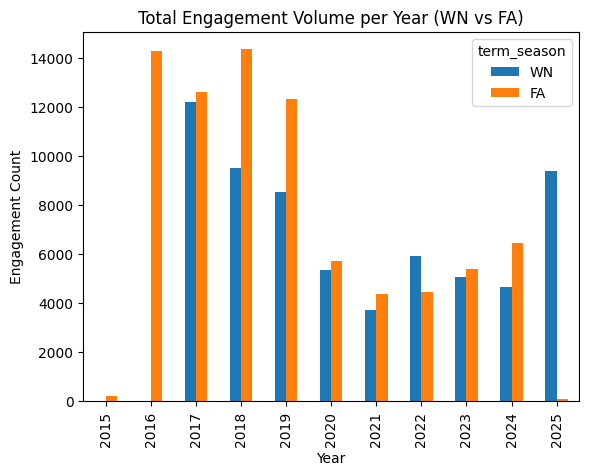

In [143]:
engagements = (
    df.groupby(["year", "term_season"])["experience_id"]
    .count()
    .reset_index(name="count")
)

pivot = engagements.pivot(index="year", columns="term_season", values="count").fillna(0)
pivot = pivot.reindex(columns=["WN", "FA"], fill_value=0)

pivot.plot(kind='bar')
plt.title("Total Engagement Volume per Year (WN vs FA)")
plt.xlabel("Year")
plt.ylabel("Engagement Count")
plt.show()

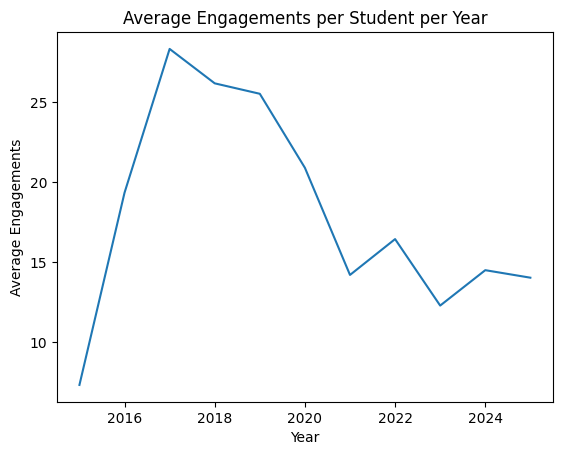

In [144]:
# Average Engagements per Student per Year
per_student_year = (
    df.groupby(["year", "student_id"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_per_year = per_student_year.groupby("year")["engagements"].mean()

plt.figure()
avg_per_year.plot()
plt.title("Average Engagements per Student per Year")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.show()

<Figure size 640x480 with 0 Axes>

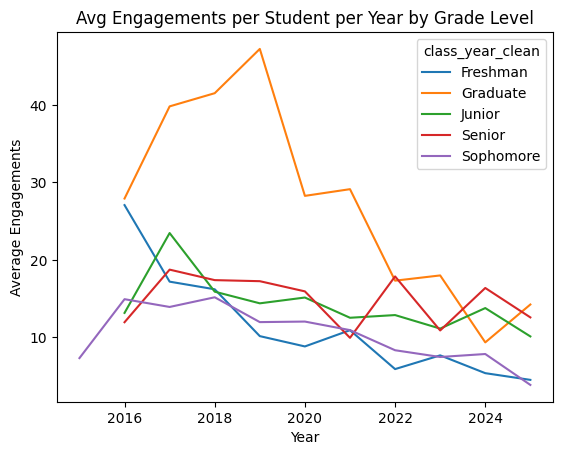

In [145]:
# Avg Engagements per Student per Year by Grade Level
per_student_year_class = (
    df.groupby(["year", "student_id", "class_year_clean"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_by_class = (
    per_student_year_class
    .groupby(["year", "class_year_clean"])["engagements"]
    .mean()
    .unstack()
)

plt.figure()
avg_by_class.plot()
plt.title("Avg Engagements per Student per Year by Grade Level")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.show()

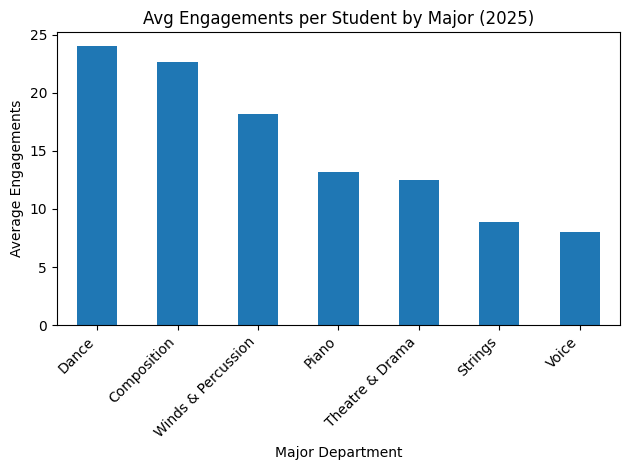

In [146]:
# Step 1: filter majors with > 1000 occurrences (across full dataset)
valid_majors = (
    df["major_department"]
    .value_counts()
    .loc[lambda x: x > 3000]
    .index
)

# Step 2: filter for 2025 + valid majors
df_2025 = df[
    (df["year"] == 2025) &
    (df["major_department"].isin(valid_majors))
]

# Step 3: engagements per student per major
per_student_major = (
    df_2025.groupby(["student_id", "major_department"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

# Step 4: average engagements per major
avg_by_major_2025 = (
    per_student_major
    .groupby("major_department")["engagements"]
    .mean()
    .sort_values(ascending=False)
)

# Step 5: bar chart
plt.figure()
avg_by_major_2025.plot(kind="bar")
plt.title("Avg Engagements per Student by Major (2025)")
plt.xlabel("Major Department")
plt.ylabel("Average Engagements")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

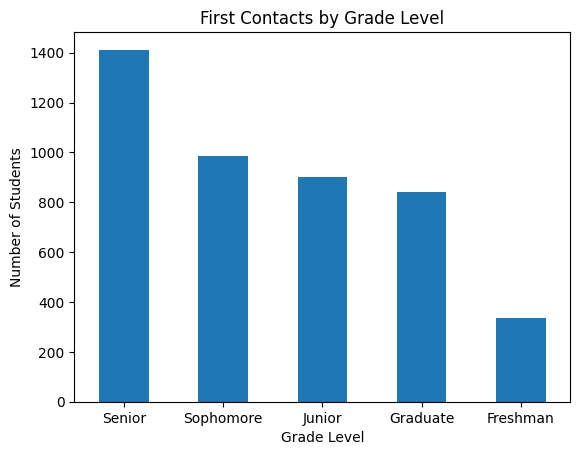

In [147]:
# First engagement per student
first_contact = (
    df.groupby("student_id")[["year", "term_num", "class_year_clean"]]
    .first()
    .reset_index()
)

first_counts = first_contact["class_year_clean"].value_counts()

plt.figure()
first_counts.plot(kind="bar")
plt.title("First Contacts by Grade Level")
plt.xlabel("Grade Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()